PAX-Ray has a lot of organs, but not all of them are present in every image.

And there are some organs that we don't want to include in the dataset, like the spine, vertebrae and ribs.

In [2]:
# Complete organ list

import json         
label_dict = json.load(open("../PAX-Ray/DATA/paxray_labels.json", "r"))["label_dict"]
label_dict

{'0': 'spine',
 '1': 'cervical spine',
 '2': 'thoracic spine',
 '3': 'lumbar spine',
 '4': 'vertebrae C1',
 '5': 'vertebrae C2',
 '6': 'vertebrae C3',
 '7': 'vertebrae C4',
 '8': 'vertebrae C5',
 '9': 'vertebrae C6',
 '10': 'vertebrae C7',
 '11': 'vertebrae T1',
 '12': 'vertebrae T2',
 '13': 'vertebrae T3',
 '14': 'vertebrae T4',
 '15': 'vertebrae T5',
 '16': 'vertebrae T6',
 '17': 'vertebrae T7',
 '18': 'vertebrae T8',
 '19': 'vertebrae T9',
 '20': 'vertebrae T10',
 '21': 'vertebrae T11',
 '22': 'vertebrae T12',
 '23': 'vertebrae L1',
 '24': 'vertebrae L2',
 '25': 'vertebrae L3',
 '26': 'vertebrae L4',
 '27': 'vertebrae L5',
 '28': 'rib_cartilage',
 '29': 'sternum',
 '30': 'clavicles',
 '31': 'clavicle left',
 '32': 'clavicle right',
 '33': 'scapulas',
 '34': 'scapula left',
 '35': 'scapula right',
 '36': 'posterior 12th rib right',
 '37': 'posterior 12th rib left',
 '38': 'anterior 11th rib right',
 '39': 'posterior 11th rib right',
 '40': 'anterior 11th rib left',
 '41': 'posterior 

So we will define a subset of organs that we want to include in the dataset.

In [3]:
organs_list = [
    "sternum",
    "clavicle left",
    "clavicle right",
    "scapula left",
    "scapula right",
    "stomach",
    "liver",
    "kidney left",
    "kidney right",
    "heart",
    "heart atrium left",
    "heart atrium right",
    "heart myocardium",
    "heart ventricle left",
    "heart ventricle right",
    "trachea",
    "aorta",
    "ascending aorta",
    "descending aorta",
    "aortic arch",
    "inferior vena cava",
    "esophagus",
    "diaphragm",
    "left hemidiaphragm",
    "right hemidiaphragm",
    "right lung",
    "left lung",
    "right upper zone lung",
    "right mid zone lung",
    "right lung base",
    "right apical zone lung",
    "left upper zone lung",
    "left mid zone lung",
    "left lung base",
    "left apical zone lung",
    'breast left',
    'breast right'
]

# Filter the label_dict to only include the organs in the organs_list
filtered_label_dict = {k: v for k, v in label_dict.items() if v in organs_list}
filtered_label_dict

{'29': 'sternum',
 '31': 'clavicle left',
 '32': 'clavicle right',
 '34': 'scapula left',
 '35': 'scapula right',
 '105': 'diaphragm',
 '106': 'left hemidiaphragm',
 '107': 'right hemidiaphragm',
 '108': 'stomach',
 '111': 'liver',
 '113': 'kidney left',
 '114': 'kidney right',
 '121': 'heart',
 '122': 'heart atrium left',
 '123': 'heart atrium right',
 '124': 'heart myocardium',
 '125': 'heart ventricle left',
 '126': 'heart ventricle right',
 '127': 'aorta',
 '128': 'ascending aorta',
 '129': 'descending aorta',
 '130': 'aortic arch',
 '132': 'inferior vena cava',
 '133': 'esophagus',
 '135': 'right lung',
 '136': 'left lung',
 '141': 'right upper zone lung',
 '142': 'right mid zone lung',
 '143': 'right lung base',
 '144': 'right apical zone lung',
 '145': 'left upper zone lung',
 '146': 'left mid zone lung',
 '147': 'left lung base',
 '148': 'left apical zone lung',
 '154': 'trachea',
 '157': 'breast left',
 '158': 'breast right'}

But there are some issues, some organs include other sub-organs. For example, the "left lung" includes the "left lung base" and the "left apical zone lung".

37


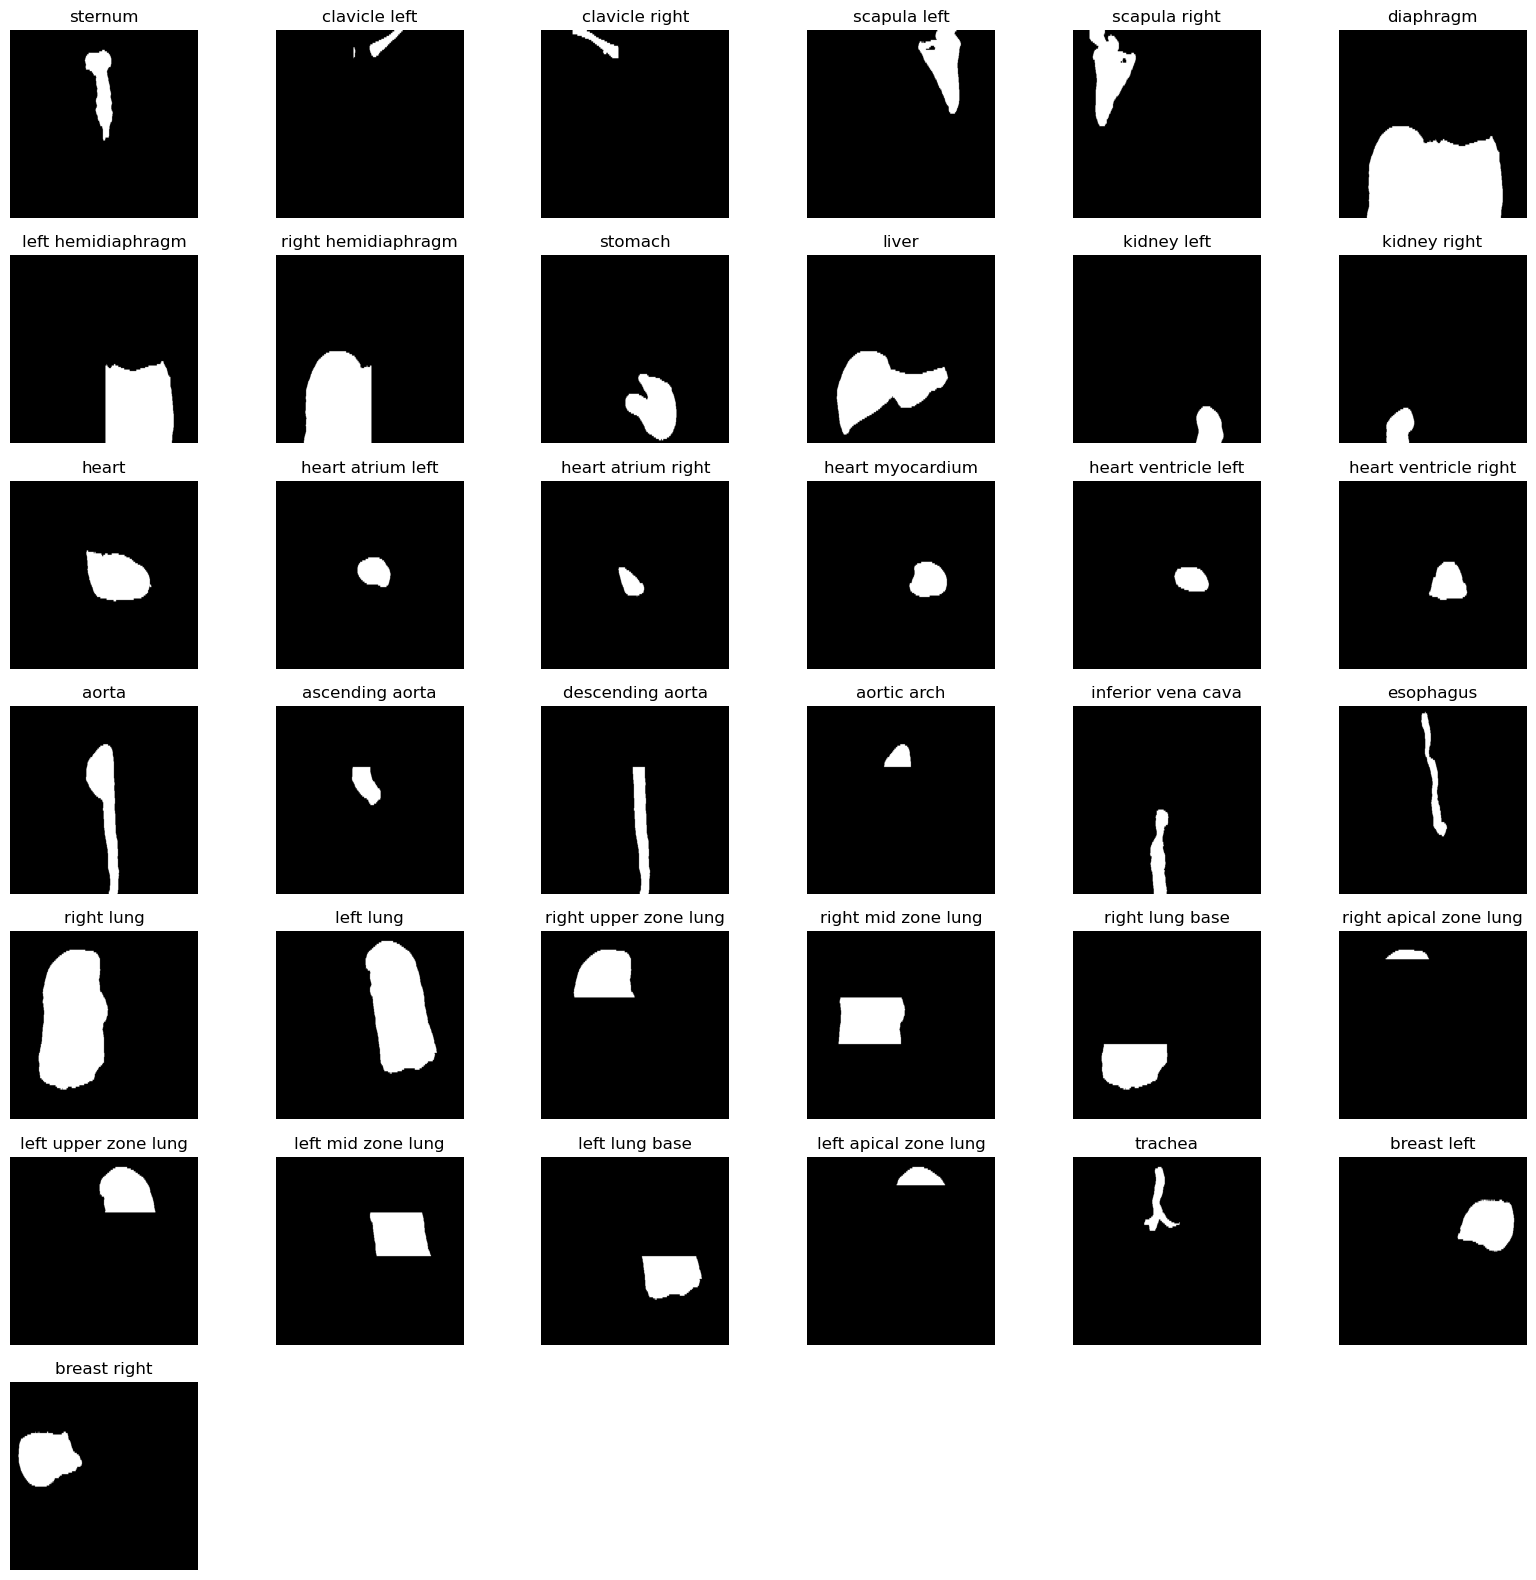

In [4]:
import numpy as np 
import matplotlib.pyplot as plt

subset_organs = filtered_label_dict.keys()
subset_organs = list(subset_organs)
subset_organs = [int(org) for org in subset_organs]
subset_organs = np.array(subset_organs)
print(len(subset_organs))

frontal_label = np.load("../PAX-Ray/labels/0001a_frontal.npy")[subset_organs]

plt.figure(figsize=(20, 20))
for i, organ in enumerate(subset_organs):
    plt.subplot(7, 6, i + 1)
    plt.imshow(frontal_label[i], cmap='gray')
    plt.title(filtered_label_dict[str(organ)])
    plt.axis('off')

In [5]:
# separate keys and values in two matching lists
organs = list(filtered_label_dict.keys())
organ_names = list(filtered_label_dict.values())

In [6]:
from utils.image_processing import sitk_load
import json
import os
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

CONFIG = {
    "database_path": "../PAX-Ray/DATA/paxray_images_unfiltered/images_patlas",
    "output_path": "../Dataset/PAXRay_Front/Landmarks_3_10",
    "scale_factor": 0.10, # 10% of the original average contour size
    "resolutions": ["full", "half", "quarter"], # Names are only for reference
    # 1, 1/2, 1/4 are the actual scale factors
    "organs": organs, # Organ ID
    "organ_names": organ_names, # Organ names
    "inputsize": 512,
    # Set up data augmentation available
    "flip_h": False, # Allows for horizontal flipping
    "flip_v": False, # Allows for vertical flipping
    "rotate": True, # Allows for small rotations
    "transpose": False # Allows for transposing the image (swapping width and height)
}

os.makedirs(CONFIG["output_path"], exist_ok=True)
with open(os.path.join(CONFIG["output_path"], "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=4)

First, we organize the dataset in folders:

images/ ...

masks/ ...

This reorganization is not required if the masks are provided in a file, with a list of paths.

In [7]:
def organize_dataset(config):
    """
    Organizes the dataset into images and masks folders and creates a file list.
    
    Args:
    config (dict): Configuration dictionary containing paths and other settings.
    
    Returns:
    tuple: (image_list_path, mask_list_path)
    """
    image_dir = Path(config['output_path']) / 'images'
    landmarks_dir = Path(config['output_path']) / 'landmarks'
    
    image_dir.mkdir(parents=True, exist_ok=True)
    landmarks_dir.mkdir(parents=True, exist_ok=True)
    
    image_list = []
    
    count = 0
    N = len(list(Path(config['database_path']).iterdir()))
    
    # This part will need to be adapted for each specific dataset
    for patient in Path(config['database_path']).iterdir():
        if ".png" not in str(patient) or "lateral" in str(patient):
            count += 1
            continue
        
        image_path = patient
        image_id = image_path.stem
        label_path = "../PAX-Ray/labels/" + image_id + ".npy"
        landmark_path = landmarks_dir / f"{image_id}.json"
        
        if not os.path.exists(label_path):        
            count += 1
            continue
        
        #if landmark_path.exists():
        #    image_list.append(str(image_id + ".png"))
        #    count += 1
        #    continue
        
        image_array = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        new_image_path = image_dir / f"{image_id}.png"
        
        cv2.imwrite(str(new_image_path), image_array)
        
        print(f"Processing image: {image_id}", "count:", count, "of", N)
        
        # now for landmarks 
        landmarks = {}
        
        frontal_label = np.load(label_path)
        
        for organ_id, organ_name in zip(config['organs'], config['organ_names']):
            organ_id = int(organ_id)
            organ_mask = frontal_label[organ_id]
            organ_mask = organ_mask.astype(np.uint8) * 255
            contours, _ = cv2.findContours(organ_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
            
            if not contours:
                continue
            
            largest_contour = max(contours, key=cv2.contourArea)
            
            if largest_contour.shape[0] < 10:
                print(f"Skipping organ {organ_name} (ID: {organ_id})")
                continue
            
            landmarks[str(organ_id)] = largest_contour.reshape(-1, 2).tolist()

        # now for landmarks 
        
        image_list.append(str(image_id + ".png"))
        
        with open(landmark_path, 'w') as f:
            json.dump(landmarks, f)
        
        count += 1
        
    # Write file lists
    image_list_path = Path(config['output_path']) / 'image_list.txt'
    
    with open(image_list_path, 'w') as f:
        f.write('\n'.join(image_list))
    
    return

In [8]:
# Step 1: Organize dataset
organize_dataset(CONFIG)

Processing image: COVID1910_0341_frontal count: 6 of 17762
Processing image: 0107a_frontal count: 8 of 17762
Processing image: RSNAPE_5f93a3abe60e_70559e308e9a_frontal count: 9 of 17762
Processing image: RSNAPE_5b060419d64d_8b4052412b21_frontal count: 14 of 17762
Processing image: RSNAPE_ab46d65a05a1_00376aeb1ec4_frontal count: 17 of 17762
Processing image: RSNAPE_e24785556a9b_366eb34cbc0a_frontal count: 18 of 17762
Processing image: RSNAPE_0d5307d3479b_0a571708d325_frontal count: 20 of 17762
Processing image: RSNAPE_3d66245a1865_181699bfcec1_frontal count: 22 of 17762
Processing image: RSNAPE_6355cfb11a74_8b7a8641e8aa_frontal count: 23 of 17762
Processing image: RSNAPE_e1f7e5e94923_4b75dd72dbd7_frontal count: 25 of 17762
Processing image: RSNAPE_bbb8a353faa2_8b604179d15a_frontal count: 26 of 17762
Processing image: RSNAPE_9840d3ea5df2_cb483eb8000c_frontal count: 28 of 17762
Processing image: RSNAPE_bb0c399591eb_9a3086d22cd3_frontal count: 29 of 17762
Processing image: RSNAPE_71fe7ce0b

In [19]:
from utils.image_processing import get_contour_lengths

# Step 3: Get contour lengths
contour_lengths = get_contour_lengths(CONFIG, os.path.join(CONFIG["output_path"], "landmarks"))

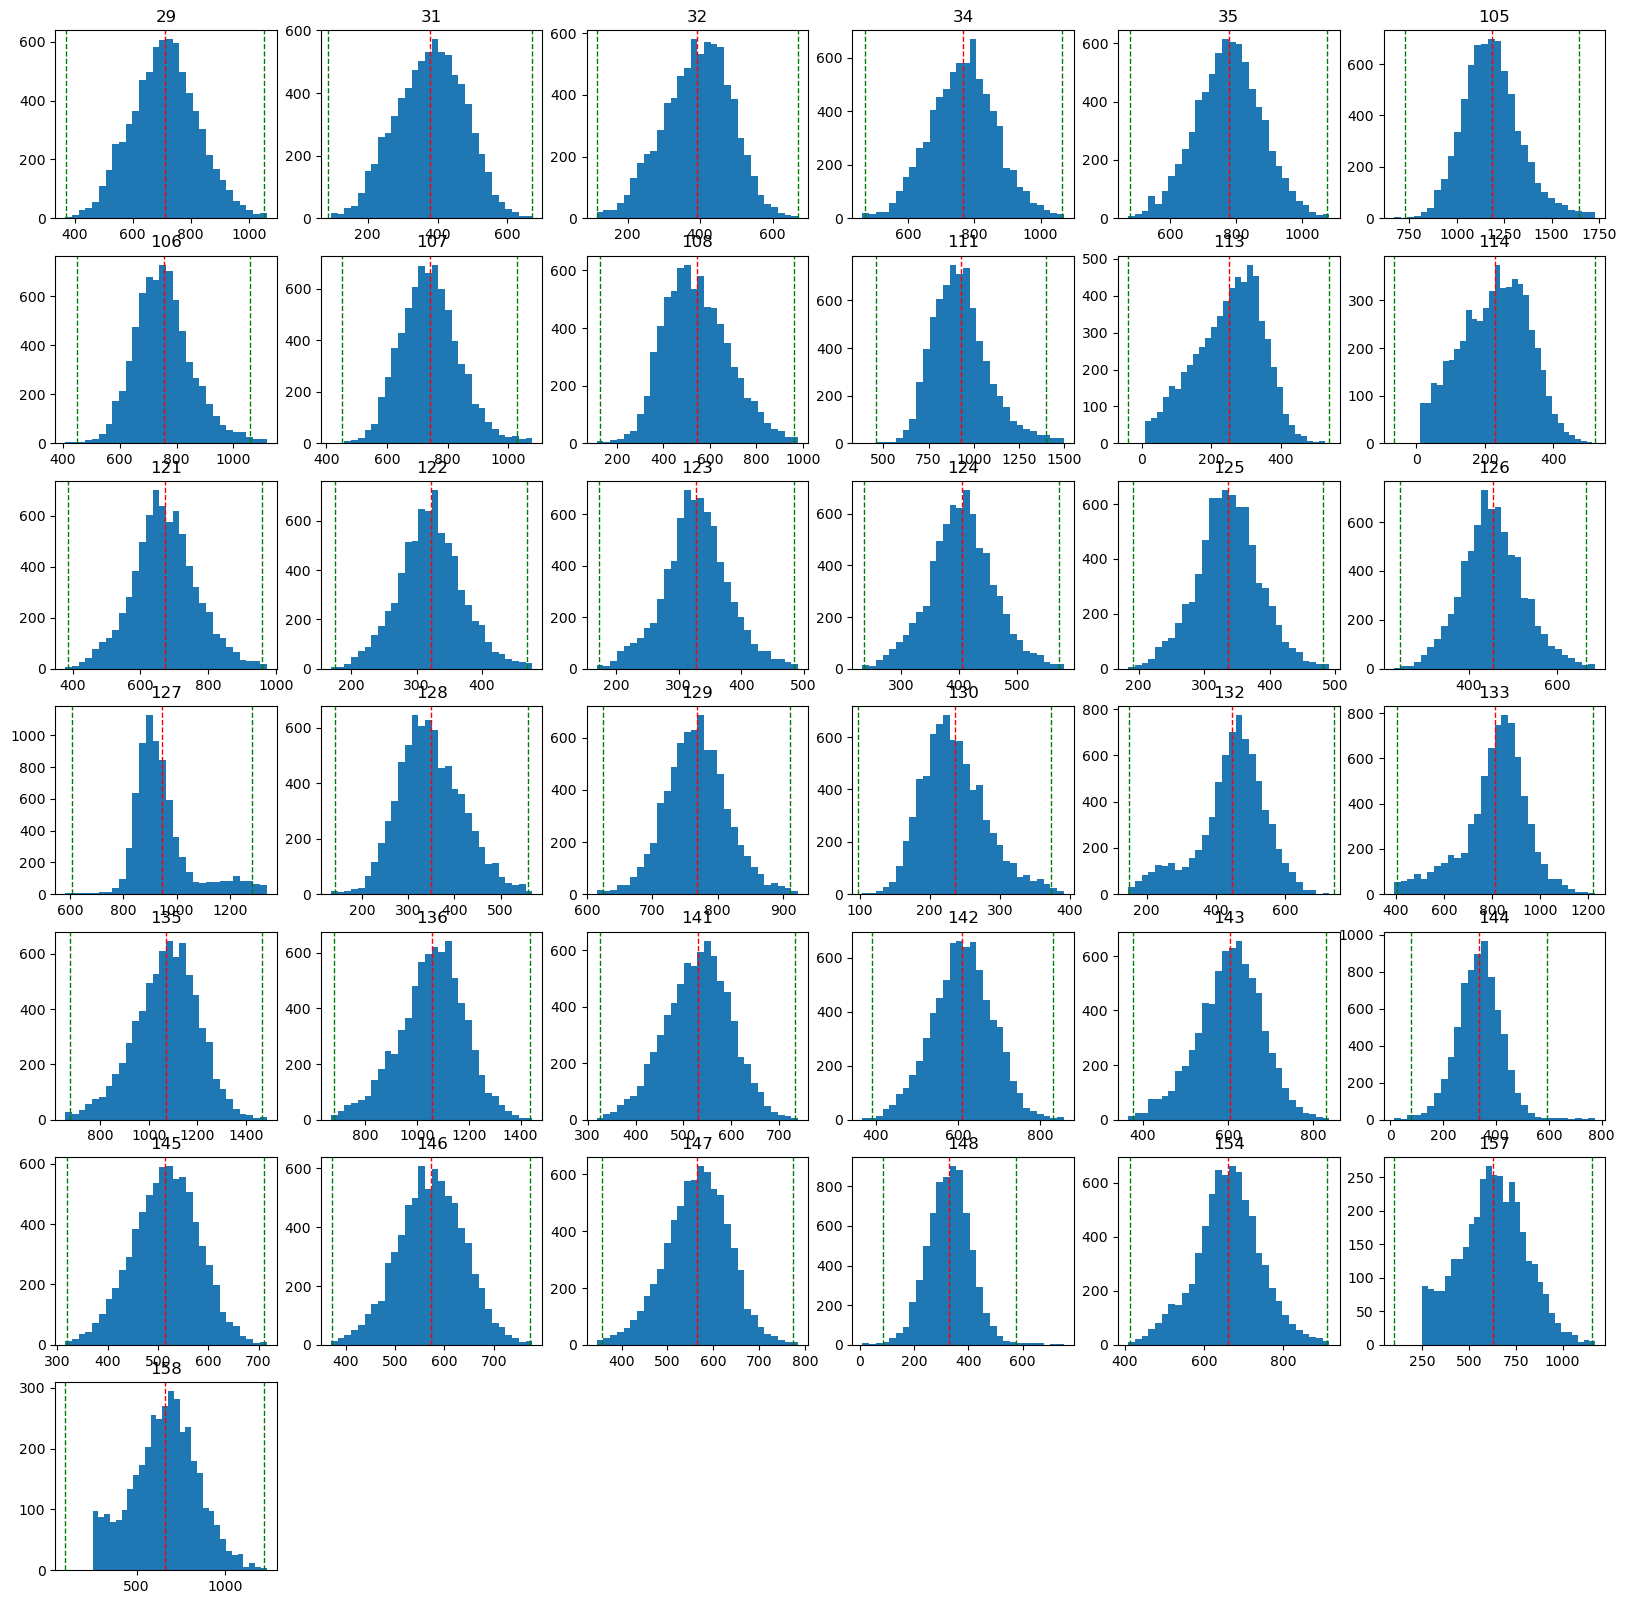

In [20]:
organ_stats = {}

for i, j in enumerate(contour_lengths.keys()):
    organ_stats[j] = {
        'mean': np.mean(contour_lengths[j]),
        'std': np.std(contour_lengths[j])
    }

plt.figure(figsize=(20, 20))

for i, j in enumerate(contour_lengths.keys()):
    plt.subplot(7, 6, i+1)
    plt.hist(contour_lengths[j], bins=30)
    plt.title(j)
    # draw the mean and std
    mean = organ_stats[j]['mean']
    std = organ_stats[j]['std']
    plt.axvline(mean, color='r', linestyle='dashed', linewidth=1)
    plt.axvline(mean + 3 * std, color='g', linestyle='dashed', linewidth=1)
    plt.axvline(mean - 3 * std, color='g', linestyle='dashed', linewidth=1)


In [17]:
# I want to iterate over the original landmarks and purge the ones that are too small
image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'
image_list = []
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()
    
for image_name in image_list:
    landmark_path = Path(CONFIG['output_path']) / 'landmarks' / f"{Path(image_name).stem}.json"
    
    if not landmark_path.exists():
        continue
    
    with open(landmark_path, 'r') as f:
        landmarks = json.load(f)

    new_dict = {}
    for organ_id, contour in landmarks.items():
        if len(contour) < (organ_stats[organ_id]['mean'] - 3 * organ_stats[organ_id]['std']):
            continue
        elif len(contour) > (organ_stats[organ_id]['mean'] + 3 * organ_stats[organ_id]['std']):
            continue     
        elif organ_id == "157" and len(contour) < 250:
            continue
        elif organ_id == "158" and len(contour) < 250:
            continue
        else:
            new_dict[organ_id] = contour
    
    # Save the updated landmarks back to the file
    with open(landmark_path, 'w') as f:
        json.dump(new_dict, f)

(np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(1.0))
(np.float64(1.0), np.float64(0.16875016875016877), np.float64(0.0), np.float64(1.0))
(np.float64(1.0), np.float64(0.33750033750033753), np.float64(0.0), np.float64(1.0))
(np.float64(1.0), np.float64(0.5062505062505063), np.float64(0.0), np.float64(1.0))
(np.float64(1.0), np.float64(0.6750006750006751), np.float64(0.0), np.float64(1.0))
(np.float64(1.0), np.float64(0.8437508437508436), np.float64(0.0), np.float64(1.0))
(np.float64(0.9749996624996625), np.float64(0.987500675000675), np.float64(0.0), np.float64(1.0))
(np.float64(0.818748818748819), np.float64(1.0), np.float64(0.0), np.float64(1.0))
(np.float64(0.6499986499986501), np.float64(1.0), np.float64(0.0), np.float64(1.0))
(np.float64(0.4812484812484813), np.float64(1.0), np.float64(0.0), np.float64(1.0))
(np.float64(0.3124983124983126), np.float64(1.0), np.float64(0.0), np.float64(1.0))
(np.float64(0.14374814374814382), np.float64(1.0), np.float64(0.0), np.float

/tmp/ipykernel_1867433/2135551271.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', n_organs)


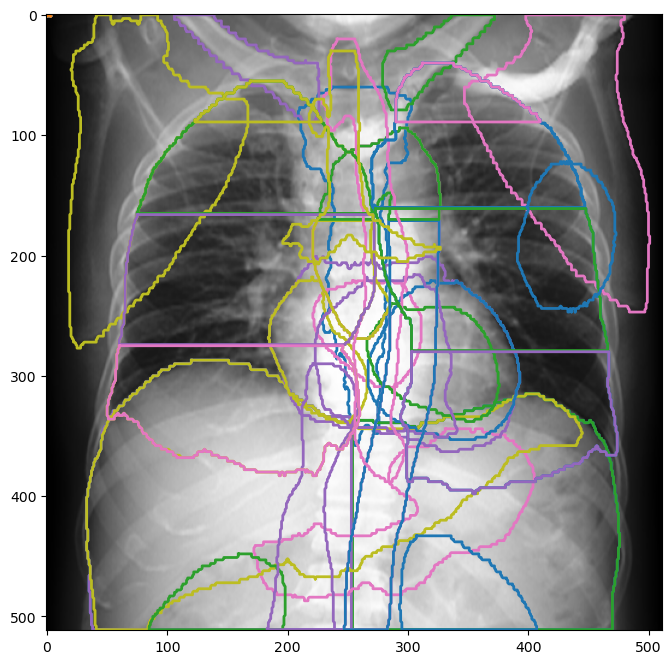

In [12]:
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()

image_path = Path(CONFIG['output_path']) / 'images' / image_list[253]
landmarks_path = Path(CONFIG['output_path']) / 'landmarks' / Path(image_list[253]).with_suffix('.json')

image = cv2.imread(str(image_path))
landmarks = json.load(open(landmarks_path))

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
n_organs = len(landmarks)
colors = plt.cm.get_cmap('hsv', n_organs)
for i, (organ, contour) in enumerate(landmarks.items()):
    color = colors(i)
    plt.plot(np.array(contour)[:, 0], np.array(contour)[:, 1], color, lw=2)
    print(color)

In [13]:
# force reload the package, with one line
import importlib
import utils.matrix_ops
importlib.reload(utils.matrix_ops)

from utils.matrix_ops import generate_adjacency_matrices, save_matrices, create_sampling_matrix, generate_edge_info

adjacency_matrices, downsampling_matrices, upsampling_matrices = generate_adjacency_matrices(contour_lengths, CONFIG)

os.makedirs(f"{CONFIG['output_path']}/Naive", exist_ok=True)

for res in CONFIG["resolutions"]:
    save_matrices(adjacency_matrices[res], res, CONFIG)

for name, matrices in downsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/Naive/downsampling_{name}.npy", block_matrix)

for name, matrices in upsampling_matrices.items():
    block_matrix = create_sampling_matrix(matrices)
    np.save(f"{CONFIG['output_path']}/Naive/upsampling_{name}.npy", block_matrix)

generate_edge_info(CONFIG)

Organ 29 - Contour len mean: 711.0605937372916 - Atlas contour size: 72
Adjacency matrices sizes: [('full', 72), ('half', 36), ('quarter', 18)]
Downsampling matrices sizes: [('to_half', 36), ('to_quarter', 18)]
Organ 31 - Contour len mean: 379.2041480276535 - Atlas contour size: 64
Adjacency matrices sizes: [('full', 64), ('half', 32), ('quarter', 16)]
Downsampling matrices sizes: [('to_half', 32), ('to_quarter', 16)]
Organ 32 - Contour len mean: 392.4514030093534 - Atlas contour size: 64
Adjacency matrices sizes: [('full', 64), ('half', 32), ('quarter', 16)]
Downsampling matrices sizes: [('to_half', 32), ('to_quarter', 16)]
Organ 34 - Contour len mean: 765.8862681306764 - Atlas contour size: 76
Adjacency matrices sizes: [('full', 76), ('half', 38), ('quarter', 19)]
Downsampling matrices sizes: [('to_half', 38), ('to_quarter', 19)]
Organ 35 - Contour len mean: 776.682120103023 - Atlas contour size: 80
Adjacency matrices sizes: [('full', 80), ('half', 40), ('quarter', 20)]
Downsampling 

Atlas landmarks shape: (2660, 2)


/tmp/ipykernel_1867433/1210387608.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', n_organs)


True

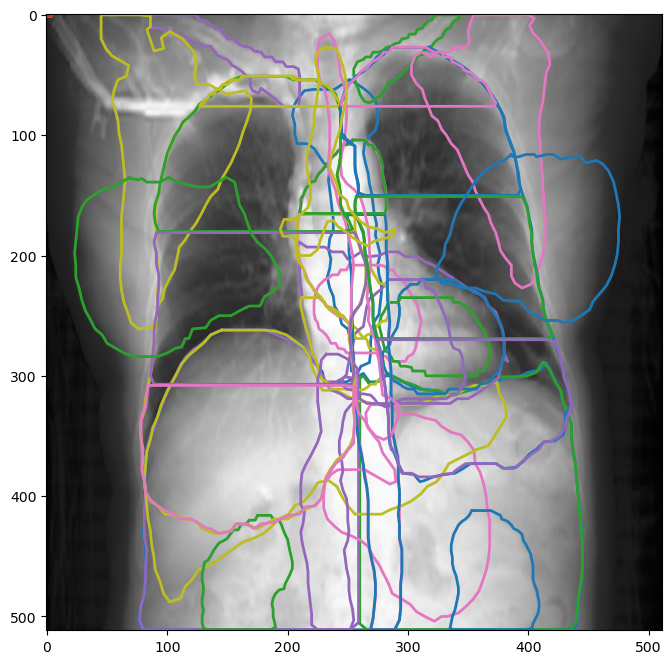

In [14]:
def interpolate_contour_linear(contour, n_points):
    """
    Interpolate contour to fixed number of points using linear interpolation.
    
    Args:
        contour: OpenCV contour (numpy array of shape (N, 1, 2))
        n_points: Target number of points
    
    Returns:
        Interpolated contour with n_points
    """
    # Reshape contour to (N, 2)
    contour = contour.reshape(-1, 2)
    
    # Calculate cumulative distances along the contour
    distances = np.sqrt(np.sum(np.diff(contour, axis=0)**2, axis=1))
    cumulative_distances = np.concatenate([[0], np.cumsum(distances)])
    
    # Create uniform sampling points
    total_length = cumulative_distances[-1]
    uniform_distances = np.linspace(0, total_length, n_points)
    
    # Interpolate x and y coordinates
    x_interp = np.interp(uniform_distances, cumulative_distances, contour[:, 0])
    y_interp = np.interp(uniform_distances, cumulative_distances, contour[:, 1])
    
    # Reshape back to OpenCV format
    interpolated_contour = np.column_stack([x_interp, y_interp])
    return interpolated_contour.reshape(-1, 1, 2).astype(np.int32)

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'
with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()

image_path = Path(CONFIG['output_path']) / 'images' / image_list[3957]
landmarks_path = Path(CONFIG['output_path']) / 'landmarks' / image_list[3957].replace('.png', '.json')

image = cv2.imread(str(image_path))
landmarks = json.load(open(landmarks_path))

atlas_landmarks = {}

i = 0
for organ in CONFIG['organs']:
    contours = landmarks.get(str(organ), None)
    if contours is None:
        print(f"Warning: Organ {organ} not found in landmarks")
        continue
    
    # approximate the contour to reduce the number of points to a fixed size,
    # 60 for first organ, 124 for second and 44 for third
    approx_size = adjacency_matrices['full'][organ].shape[0]
    
    if contours:
        contour = np.array(contours, dtype=np.int32)
        interpolated_contour = interpolate_contour_linear(contour, approx_size)
        atlas_landmarks[organ_names[i]] = interpolated_contour.reshape(-1, 2).tolist()
        i+=1
        
plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
n_organs = len(landmarks)
colors = plt.cm.get_cmap('hsv', n_organs)
for i, (organ, contour) in enumerate(atlas_landmarks.items()):
    color = colors(i)
    plt.plot(np.array(contour)[:, 0], np.array(contour)[:, 1], color, lw=2)

atlas_array = []
# save the atlas landmarks as an array using the same order as the adjacency matrices
i = 0
for organ in CONFIG['organs']:
    organ_name = CONFIG['organ_names'][i]
    i+= 1
    if organ_name in atlas_landmarks:
        atlas_array.append(np.array(atlas_landmarks[organ_name]))
    else:
        print(f"Warning: {organ_name} not found in atlas landmarks")

#concatenate
atlas_landmarks = np.concatenate(atlas_array, axis=0)
print("Atlas landmarks shape:", atlas_landmarks.shape)

# now save the atlas landmarks to a npy file
atlas_landmarks_path = Path(CONFIG['output_path']) / 'Naive/atlas_pos.npy'
np.save(atlas_landmarks_path, atlas_landmarks)
# and save the image
cv2.imwrite(str(Path(CONFIG['output_path']) / 'Naive/atlas_image.png'), image)

In [70]:
# Load the files .txt and separate them in training validation and test. Use a 80 - 10 - 10 split
import numpy as np
import random

image_list_path = Path(CONFIG['output_path']) / 'image_list.txt'

with open(image_list_path, 'r') as f:
    image_list = f.read().splitlines()
    
# samples should be taking without putting the same patient in different sets
# the list contains files in the format patient/type/image.png
# so first separate the files by patient

patients = {}
for image in image_list:
    patient = image.split('/')[0]
    if patient not in patients:
        patients[patient] = []
    patients[patient].append(image)

# now we have a dictionary with the patient as key and a list of images as value
# we can now split the patients in training, validation and test
# we will use a 80 - 10 - 10 split

n_patients = len(patients)
n_train = int(0.8 * n_patients)
n_test = int(0.1 * n_patients)
n_val = n_patients - n_train - n_test

random.seed(42)
patients = list(patients.items())
random.shuffle(patients)

train_patients = patients[:n_train]
val_patients = patients[n_train:n_train+n_val]
test_patients = patients[n_train+n_val:]

train_images = []
val_images = []
test_images = []

for patient, images in train_patients:
    train_images.extend(images)
for patient, images in val_patients:
    val_images.extend(images)
for patient, images in test_patients:
    test_images.extend(images)

# save as txt

train_image_list_path = Path(CONFIG['output_path']) / 'train.txt'
val_image_list_path = Path(CONFIG['output_path']) / 'val.txt'
test_image_list_path = Path(CONFIG['output_path']) / 'test.txt'

with open(train_image_list_path, 'w') as f:
    f.write('\n'.join(train_images))
with open(val_image_list_path, 'w') as f:
    f.write('\n'.join(val_images))
with open(test_image_list_path, 'w') as f:
    f.write('\n'.join(test_images))